In [1]:
import numpy as np
import os
from PIL import Image
import argparse

# Define the class information - keeping all original classes and adding the new one
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]},
    18: {"name": "point_mask", "rgb": [100, 100, 100]}  # NEW CLASS ADDED
}

# Create a lookup table for fast conversion
max_val = 256
lookup_table = np.zeros((max_val, max_val, max_val), dtype=np.uint8)

# Fill the lookup table with class indices
for class_idx, class_info in CLASS_INFO.items():
    r, g, b = class_info["rgb"]
    lookup_table[r, g, b] = class_idx

def rgb_to_one_channel(rgb_mask):
    """
    Convert RGB mask to 1-channel mask with class indices.
    
    Args:
        rgb_mask: numpy array of shape (H, W, 3) with RGB values
        
    Returns:
        one_channel_mask: numpy array of shape (H, W) with class indices
    """
    # Extract RGB channels
    r = rgb_mask[:, :, 0]
    g = rgb_mask[:, :, 1]
    b = rgb_mask[:, :, 2]
    
    # Use the lookup table to convert RGB to class indices
    return lookup_table[r, g, b]

def one_channel_to_rgb(one_channel_mask):
    """
    Convert 1-channel mask back to RGB for visualization.
    
    Args:
        one_channel_mask: numpy array of shape (H, W) with class indices
        
    Returns:
        rgb_mask: numpy array of shape (H, W, 3) with RGB values
    """
    h, w = one_channel_mask.shape
    rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
    
    for class_idx in CLASS_INFO:
        mask = one_channel_mask == class_idx
        rgb_mask[mask] = CLASS_INFO[class_idx]["rgb"]
    
    return rgb_mask

def process_masks(input_folder, output_folder):
    """
    Convert all RGB masks in input_folder to 1-channel masks and save to output_folder.
    
    Args:
        input_folder: path to folder containing RGB masks
        output_folder: path to folder where 1-channel masks will be saved
    """
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Get all image files in input folder
    supported_formats = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
    image_files = [f for f in os.listdir(input_folder) 
                  if f.lower().endswith(supported_formats)]
    
    print(f"Found {len(image_files)} masks to process in {input_folder}")
    
    # Process each image
    for i, filename in enumerate(image_files):
        # Load RGB mask
        rgb_path = os.path.join(input_folder, filename)
        rgb_mask = np.array(Image.open(rgb_path))
        
        # Convert to 1-channel
        one_channel_mask = rgb_to_one_channel(rgb_mask)
        
        # Save as PNG (preserves single channel data)
        name, ext = os.path.splitext(filename)
        output_path = os.path.join(output_folder, f"{name}.png")
        
        # Save as PNG with 8-bit depth
        Image.fromarray(one_channel_mask).save(output_path)
        
        if (i + 1) % 10 == 0 or (i + 1) == len(image_files):
            print(f"Processed {i+1}/{len(image_files)}: {filename} -> {output_path}")
    
    print(f"All masks converted and saved to {output_folder}")

def verify_conversion(input_folder, output_folder):
    """
    Verify that the conversion was correct by checking a few samples.
    """
    # Get a few files to verify
    sample_files = [f for f in os.listdir(input_folder) if f.endswith('.png')][:3]
    
    for filename in sample_files:
        # Load original RGB mask
        rgb_path = os.path.join(input_folder, filename)
        rgb_mask = np.array(Image.open(rgb_path))
        
        # Load converted 1-channel mask
        name, ext = os.path.splitext(filename)
        one_channel_path = os.path.join(output_folder, f"{name}.png")
        one_channel_mask = np.array(Image.open(one_channel_path))
        
        # Convert back to RGB using our function for verification
        reconstructed_rgb = one_channel_to_rgb(one_channel_mask)
        
        # Check if they match
        matches = np.array_equal(rgb_mask, reconstructed_rgb)
        print(f"Verification for {filename}: {'PASS' if matches else 'FAIL'}")
        
        if not matches:
            print(f"  Original shape: {rgb_mask.shape}, Converted shape: {one_channel_mask.shape}")
            print(f"  Unique values in original: {np.unique(rgb_mask.reshape(-1, 3), axis=0)}")
            print(f"  Unique values in converted: {np.unique(one_channel_mask)}")

def analyze_colors(input_folder):
    """
    Analyze what colors are present in the masks to help debug.
    """
    sample_files = [f for f in os.listdir(input_folder) if f.endswith('.png')][:2]
    
    for filename in sample_files:
        rgb_path = os.path.join(input_folder, filename)
        rgb_mask = np.array(Image.open(rgb_path))
        
        unique_colors = np.unique(rgb_mask.reshape(-1, 3), axis=0)
        print(f"File: {filename}")
        print(f"Unique colors present: {unique_colors}")
        
        # Check if (100,100,100) is present
        has_point_mask = any(np.array_equal(color, [100, 100, 100]) for color in unique_colors)
        print(f"Contains (100,100,100): {has_point_mask}")
        print("---")

def main():
    """Main function with predefined paths"""
    # Define your paths here
    input_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_all_regions_1'  # CHANGE THIS to your RGB masks folder
    output_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_1cmasks'  # CHANGE THIS to your output folder
    
    # Check if input folder exists
    if not os.path.exists(input_folder):
        print(f"Error: Input folder '{input_folder}' does not exist!")
        return
    
    # First, analyze what colors are in your masks
    print("Analyzing colors in your masks...")
    analyze_colors(input_folder)
    
    # Process all masks
    print("\nStarting mask conversion...")
    process_masks(input_folder, output_folder)
    
    # Verify conversion
    print("\nVerifying conversion...")
    verify_conversion(input_folder, output_folder)
    
    print("\nConversion completed successfully!")
    print(f"Total classes: {len(CLASS_INFO)}")
    print("New class added: Class 18 - point_mask (RGB: [100, 100, 100])")

if __name__ == "__main__":
    main()

Analyzing colors in your masks...
File: 251.png
Unique colors present: [[  0 128 128]
 [  0 255   0]
 [100 100 100]
 [255   0   0]
 [255 255   0]]
Contains (100,100,100): True
---
File: 542.png
Unique colors present: [[  0   0 128]
 [  0 128 128]
 [  0 255   0]
 [100 100 100]
 [128 128   0]
 [255 255   0]]
Contains (100,100,100): True
---

Starting mask conversion...
Found 630 masks to process in /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_point_masks_all_regions_1
Processed 10/630: 247.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_1cmasks/247.png
Processed 20/630: 96.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_1cmasks/96.png
Processed 30/630: 32.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_1cmasks/32.png
Processed 40/630: 344.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_1cmasks/344.png
Processed 50/630: 92.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_1cmasks/92.png
Processed 60/

In [1]:
import numpy as np
import os
from PIL import Image
import argparse

# Define the class information - keeping all original classes and adding the new one
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]},
    18: {"name": "point_mask", "rgb": [100, 100, 100]}  # NEW CLASS ADDED
}

# Create a lookup table for fast conversion
max_val = 256
lookup_table = np.zeros((max_val, max_val, max_val), dtype=np.uint8)

# Fill the lookup table with class indices
for class_idx, class_info in CLASS_INFO.items():
    r, g, b = class_info["rgb"]
    lookup_table[r, g, b] = class_idx

def rgb_to_one_channel(rgb_mask):
    """
    Convert RGB mask to 1-channel mask with class indices.
    
    Args:
        rgb_mask: numpy array of shape (H, W, 3) with RGB values
        
    Returns:
        one_channel_mask: numpy array of shape (H, W) with class indices
    """
    # Extract RGB channels
    r = rgb_mask[:, :, 0]
    g = rgb_mask[:, :, 1]
    b = rgb_mask[:, :, 2]
    
    # Use the lookup table to convert RGB to class indices
    return lookup_table[r, g, b]

def one_channel_to_rgb(one_channel_mask):
    """
    Convert 1-channel mask back to RGB for visualization.
    
    Args:
        one_channel_mask: numpy array of shape (H, W) with class indices
        
    Returns:
        rgb_mask: numpy array of shape (H, W, 3) with RGB values
    """
    h, w = one_channel_mask.shape
    rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
    
    for class_idx in CLASS_INFO:
        mask = one_channel_mask == class_idx
        rgb_mask[mask] = CLASS_INFO[class_idx]["rgb"]
    
    return rgb_mask

def process_masks(input_folder, output_folder):
    """
    Convert all RGB masks in input_folder to 1-channel masks and save to output_folder.
    
    Args:
        input_folder: path to folder containing RGB masks
        output_folder: path to folder where 1-channel masks will be saved
    """
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Get all image files in input folder
    supported_formats = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
    image_files = [f for f in os.listdir(input_folder) 
                  if f.lower().endswith(supported_formats)]
    
    print(f"Found {len(image_files)} masks to process in {input_folder}")
    
    # Process each image
    for i, filename in enumerate(image_files):
        # Load RGB mask
        rgb_path = os.path.join(input_folder, filename)
        rgb_mask = np.array(Image.open(rgb_path))
        
        # Convert to 1-channel
        one_channel_mask = rgb_to_one_channel(rgb_mask)
        
        # Save as PNG (preserves single channel data)
        name, ext = os.path.splitext(filename)
        output_path = os.path.join(output_folder, f"{name}.png")
        
        # Save as PNG with 8-bit depth
        Image.fromarray(one_channel_mask).save(output_path)
        
        if (i + 1) % 10 == 0 or (i + 1) == len(image_files):
            print(f"Processed {i+1}/{len(image_files)}: {filename} -> {output_path}")
    
    print(f"All masks converted and saved to {output_folder}")

def verify_conversion(input_folder, output_folder):
    """
    Verify that the conversion was correct by checking a few samples.
    """
    # Get a few files to verify
    sample_files = [f for f in os.listdir(input_folder) if f.endswith('.png')][:3]
    
    for filename in sample_files:
        # Load original RGB mask
        rgb_path = os.path.join(input_folder, filename)
        rgb_mask = np.array(Image.open(rgb_path))
        
        # Load converted 1-channel mask
        name, ext = os.path.splitext(filename)
        one_channel_path = os.path.join(output_folder, f"{name}.png")
        one_channel_mask = np.array(Image.open(one_channel_path))
        
        # Convert back to RGB using our function for verification
        reconstructed_rgb = one_channel_to_rgb(one_channel_mask)
        
        # Check if they match
        matches = np.array_equal(rgb_mask, reconstructed_rgb)
        print(f"Verification for {filename}: {'PASS' if matches else 'FAIL'}")
        
        if not matches:
            print(f"  Original shape: {rgb_mask.shape}, Converted shape: {one_channel_mask.shape}")
            print(f"  Unique values in original: {np.unique(rgb_mask.reshape(-1, 3), axis=0)}")
            print(f"  Unique values in converted: {np.unique(one_channel_mask)}")

def analyze_colors(input_folder):
    """
    Analyze what colors are present in the masks to help debug.
    """
    sample_files = [f for f in os.listdir(input_folder) if f.endswith('.png')][:2]
    
    for filename in sample_files:
        rgb_path = os.path.join(input_folder, filename)
        rgb_mask = np.array(Image.open(rgb_path))
        
        unique_colors = np.unique(rgb_mask.reshape(-1, 3), axis=0)
        print(f"File: {filename}")
        print(f"Unique colors present: {unique_colors}")
        
        # Check if (100,100,100) is present
        has_point_mask = any(np.array_equal(color, [100, 100, 100]) for color in unique_colors)
        print(f"Contains (100,100,100): {has_point_mask}")
        print("---")

def main():
    """Main function with predefined paths"""
    # Define your paths here
    input_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_point_masks'  # CHANGE THIS to your RGB masks folder
    output_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_point_1cmasks'  # CHANGE THIS to your output folder
    
    # Check if input folder exists
    if not os.path.exists(input_folder):
        print(f"Error: Input folder '{input_folder}' does not exist!")
        return
    
    # First, analyze what colors are in your masks
    print("Analyzing colors in your masks...")
    analyze_colors(input_folder)
    
    # Process all masks
    print("\nStarting mask conversion...")
    process_masks(input_folder, output_folder)
    
    # Verify conversion
    print("\nVerifying conversion...")
    verify_conversion(input_folder, output_folder)
    
    print("\nConversion completed successfully!")
    print(f"Total classes: {len(CLASS_INFO)}")
    print("New class added: Class 18 - point_mask (RGB: [100, 100, 100])")

if __name__ == "__main__":
    main()

Analyzing colors in your masks...
File: freew_310.png
Unique colors present: [[  0 255   0]
 [100 100 100]
 [255   0   0]
 [255 255   0]]
Contains (100,100,100): True
---
File: agric_1934.png
Unique colors present: [[100 100 100]
 [160 160 164]]
Contains (100,100,100): True
---

Starting mask conversion...
Found 2100 masks to process in /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_point_masks
Processed 10/2100: mediu_1250.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_point_1cmasks/mediu_1250.png
Processed 20/2100: overp_1542.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_point_1cmasks/overp_1542.png
Processed 30/2100: dense_1458.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_point_1cmasks/dense_1458.png
Processed 40/2100: agric_1936.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_point_1cmasks/agric_1936.png
Processed 50/2100: mediu_1283.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_point_1cmask

Number of classes: 18
Ignore class ID: 18 (point_mask)
=== ANALYZING GROUND TRUTH MASKS ===
251.png: Unique class IDs: [ 4  9 11 16 18]
542.png: Unique class IDs: [ 2  3  9 11 16 18]
8.png: Unique class IDs: [ 8 18]
233.png: Unique class IDs: [16 18]
611.png: Unique class IDs: [ 3  6 11 18]
302.png: Unique class IDs: [ 7 17 18]
73.png: Unique class IDs: [ 2  3  9 18]
424.png: Unique class IDs: [ 2  4 11 18]
103.png: Unique class IDs: [12 13 18]
247.png: Unique class IDs: [ 2  4  9 11 16 18]

All unique class IDs found: [2, 3, 4, 6, 7, 8, 9, 11, 12, 13, 16, 17, 18]
Number of classes in data: 13
✅ Ignore class 18 (point_mask) found in data
Loading SAM model...
Model created with 18 classes
Ignoring class 18 (point_mask) during training
Training on 504 samples, validating on 126 samples
Starting training...


/home/iiitdmk-param/.local/lib/python3.8/site-packages/torch/optim/lr_scheduler.py:60: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1, Batch 0, Loss: 2.9995
Epoch 1, Batch 10, Loss: 1.9260
Epoch 1, Batch 20, Loss: 1.7944
Epoch 1, Batch 30, Loss: 2.0743
Epoch 1, Batch 40, Loss: 1.2956
Epoch 1, Batch 50, Loss: 2.2650
Epoch 1, Batch 60, Loss: 2.2465
Epoch 1, Batch 70, Loss: 2.1105
Epoch 1, Batch 80, Loss: 1.5395
Epoch 1, Batch 90, Loss: 1.6397
Epoch 1, Batch 100, Loss: 1.1983
Epoch 1, Batch 110, Loss: 1.4078
Epoch 1, Batch 120, Loss: 1.9166
Epoch 1, Batch 130, Loss: 1.5171
Epoch 1, Batch 140, Loss: 2.3355
Epoch 1, Batch 150, Loss: 1.1772
Epoch 1, Batch 160, Loss: 2.1224
Epoch 1, Batch 170, Loss: 1.5510
Epoch 1, Batch 180, Loss: 1.1726
Epoch 1, Batch 190, Loss: 2.5017
Epoch 1, Batch 200, Loss: 1.6031
Epoch 1, Batch 210, Loss: 1.5846
Epoch 1, Batch 220, Loss: 1.4935
Epoch 1, Batch 230, Loss: 2.7869
Epoch 1, Batch 240, Loss: 1.4693
Epoch 1, Batch 250, Loss: 2.7523
Epoch 1/100, Train Loss: 1.9218, Val Loss: 1.4293, LR: 1.00e-03
✅ Saved new best model with val loss: 1.4293
Epoch 2, Batch 0, Loss: 2.6371
Epoch 2, Batc

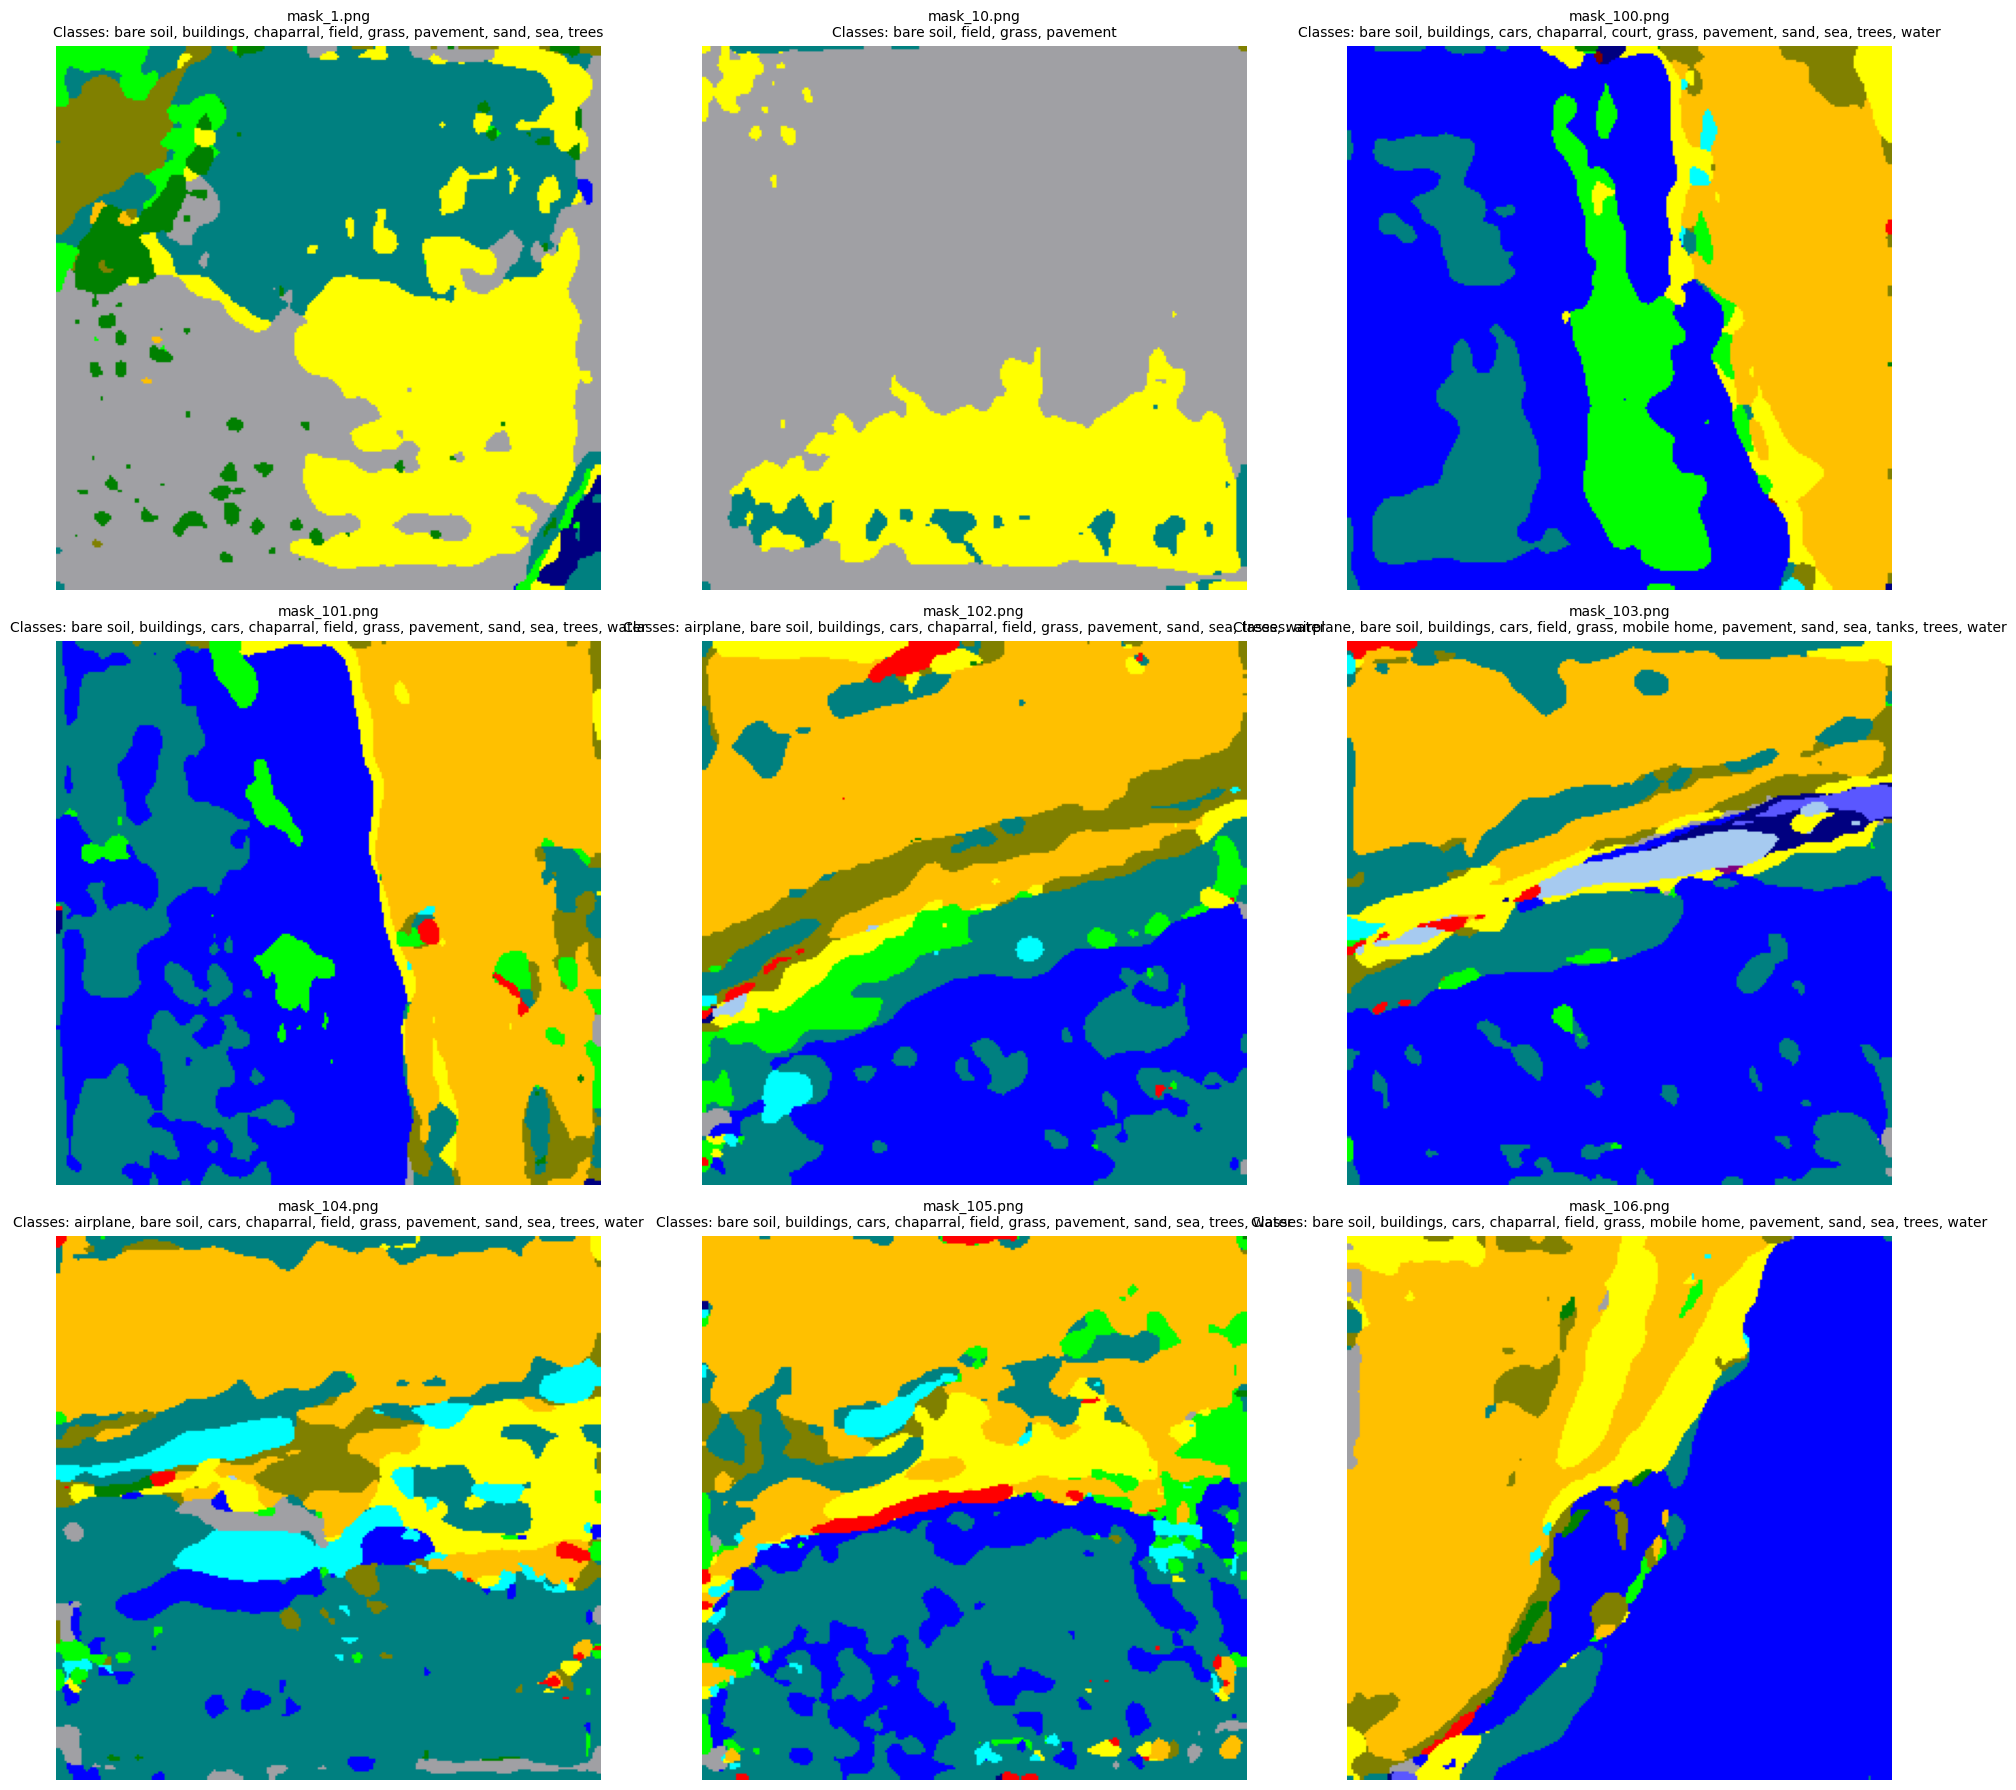

Multi-class semantic segmentation completed!


In [7]:
import torch
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from segment_anything import sam_model_registry
from torch.optim import Adam
import torch.nn as nn
from glob import glob

# ==================== CONFIGURATION ====================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
train_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_images'
train_mask_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_1cmasks'
test_image_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/train_images'
output_dir = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_finetune_sam_output'
sam_checkpoint = "/home/iiitdmk-param/Desktop/sam_vit_b.pth"
model_type = "vit_b"

# ==================== CLASS DEFINITIONS ====================
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]},
    18: {"name": "point_mask", "rgb": [100, 100, 100], "ignore": True}  # NEW CLASS TO IGNORE
}

NUM_CLASSES = len(CLASS_INFO) - 1  # Subtract 1 because we ignore point_mask class during training
IGNORE_CLASS_ID = 18  # Class ID for point_mask that should be ignored

print(f"Number of classes: {NUM_CLASSES}")
print(f"Ignore class ID: {IGNORE_CLASS_ID} (point_mask)")

# ==================== DATA ANALYSIS ====================
def analyze_ground_truth_masks(mask_dir):
    """Check what class IDs are present in ground truth masks"""
    mask_files = [f for f in os.listdir(mask_dir) if f.endswith('.png')]
    
    print("=== ANALYZING GROUND TRUTH MASKS ===")
    all_class_ids = set()
    
    for mask_file in mask_files[:10]:
        mask_path = os.path.join(mask_dir, mask_file)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        
        if mask is not None:
            unique_ids = np.unique(mask)
            all_class_ids.update(unique_ids)
            print(f"{mask_file}: Unique class IDs: {unique_ids}")
    
    class_ids = sorted(all_class_ids)
    print(f"\nAll unique class IDs found: {class_ids}")
    print(f"Number of classes in data: {len(class_ids)}")
    
    # Check if any class IDs are outside our expected range
    unexpected_classes = [cid for cid in class_ids if cid not in CLASS_INFO]
    if unexpected_classes:
        print(f"⚠️  Warning: Unexpected class IDs found: {unexpected_classes}")
    
    # Check if ignore class is present
    if IGNORE_CLASS_ID in class_ids:
        print(f"✅ Ignore class {IGNORE_CLASS_ID} (point_mask) found in data")
    
    return class_ids

# Analyze ground truth masks
class_ids = analyze_ground_truth_masks(train_mask_dir)

# ==================== MULTI-CLASS SAM WRAPPER ====================
class MultiClassSAMWrapper(nn.Module):
    def __init__(self, sam_model, num_classes):
        super().__init__()
        self.sam = sam_model
        self.num_classes = num_classes
        
        # Add custom multi-class head with more capacity
        self.multi_class_head = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
            nn.Conv2d(128, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, num_classes, 1)
        )
        
        # Freeze SAM parameters, only train custom head
        for param in self.sam.parameters():
            param.requires_grad = False
    
    def forward(self, x):
        # Get image embeddings from SAM
        with torch.no_grad():
            image_embeddings = self.sam.image_encoder(x)
        
        # Pass through multi-class head
        logits = self.multi_class_head(image_embeddings)
        return logits

# ==================== DATASET AND TRANSFORMS ====================
class SimpleTransform:
    def __call__(self, image, mask):
        # Resize to SAM input size
        image = cv2.resize(image, (1024, 1024))
        mask = cv2.resize(mask, (1024, 1024), interpolation=cv2.INTER_NEAREST)
        
        # Normalize image
        image = image.astype(np.float32) / 255.0
        image = (image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])  # ImageNet normalization
        
        # Convert to tensor
        image = torch.from_numpy(image).permute(2, 0, 1).float()
        mask = torch.from_numpy(mask).long()  # Keep as class IDs
        
        return image, mask

class MultiClassSAMDataset(Dataset):
    def __init__(self, image_dir, mask_dir, transform=None):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.transform = transform
        self.image_files = sorted([f for f in os.listdir(image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
        
    def __len__(self):
        return len(self.image_files)
    
    def __getitem__(self, idx):
        image_path = os.path.join(self.image_dir, self.image_files[idx])
        mask_name = self.image_files[idx].split('.')[0] + '.png'
        mask_path = os.path.join(self.mask_dir, mask_name)
        
        # Load image
        image = cv2.imread(image_path)
        if image is None:
            raise ValueError(f"Could not load image: {image_path}")
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
        # Load mask - keep original class IDs
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            mask = np.zeros((image.shape[0], image.shape[1]), dtype=np.uint8)
        
        # Apply transformations
        if self.transform:
            image, mask = self.transform(image, mask)
        
        return {'image': image, 'mask': mask}

# ==================== TRAINING FUNCTION ====================
def train_multi_class_sam(model, train_loader, val_loader, num_epochs=100, lr=1e-3):
    model = model.to(device)
    
    # Create class weights (ignore the point_mask class)
    class_weights = torch.ones(NUM_CLASSES).to(device)
    criterion = nn.CrossEntropyLoss(weight=class_weights, ignore_index=IGNORE_CLASS_ID)
    
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5, verbose=True)
    
    best_val_loss = float('inf')
    
    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0
        num_samples = 0
        
        for batch_idx, batch in enumerate(train_loader):
            images = batch['image'].to(device)
            masks = batch['mask'].to(device)
            
            optimizer.zero_grad()
            
            # Forward pass
            logits = model(images)
            
            # Resize logits to match mask size if needed
            if logits.shape[2:] != masks.shape[1:]:
                logits = torch.nn.functional.interpolate(
                    logits, size=masks.shape[1:], mode='bilinear', align_corners=False
                )
            
            loss = criterion(logits, masks)
            loss.backward()
            
            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            
            optimizer.step()
            
            train_loss += loss.item()
            num_samples += images.size(0)
            
            if batch_idx % 10 == 0:
                print(f'Epoch {epoch+1}, Batch {batch_idx}, Loss: {loss.item():.4f}')
        
        # Validation
        model.eval()
        val_loss = 0
        num_val_samples = 0
        
        with torch.no_grad():
            for batch in val_loader:
                images = batch['image'].to(device)
                masks = batch['mask'].to(device)
                
                logits = model(images)
                
                if logits.shape[2:] != masks.shape[1:]:
                    logits = torch.nn.functional.interpolate(
                        logits, size=masks.shape[1:], mode='bilinear', align_corners=False
                    )
                
                loss = criterion(logits, masks)
                val_loss += loss.item()
                num_val_samples += images.size(0)
        
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        
        scheduler.step(avg_val_loss)
        
        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}, LR: {optimizer.param_groups[0]["lr"]:.2e}')
        
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': best_val_loss,
                'num_classes': NUM_CLASSES,
                'class_info': CLASS_INFO,
                'ignore_class_id': IGNORE_CLASS_ID,
            }, 'best_multi_class_sam.pth')
            print(f'✅ Saved new best model with val loss: {best_val_loss:.4f}')
    
    return model

# ==================== PREDICTION FUNCTION ====================
def predict_multi_class_masks(model, test_image_dir, output_dir, device='cuda'):
    os.makedirs(output_dir, exist_ok=True)
    model.eval()
    
    image_files = sorted([f for f in os.listdir(test_image_dir) if f.endswith(('.png', '.jpg', '.jpeg'))])
    
    for image_file in image_files:
        image_path = os.path.join(test_image_dir, image_file)
        
        # Load and preprocess image
        image = cv2.imread(image_path)
        if image is None:
            print(f"Could not load image: {image_file}")
            continue
            
        original_image = image.copy()
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        original_size = image_rgb.shape[:2]
        
        # Preprocess image
        input_image = cv2.resize(image_rgb, (1024, 1024))
        input_image = input_image.astype(np.float32) / 255.0
        input_image = (input_image - np.array([0.485, 0.456, 0.406])) / np.array([0.229, 0.224, 0.225])
        
        input_image_tensor = torch.from_numpy(input_image).permute(2, 0, 1).float().to(device)
        input_image_tensor = input_image_tensor.unsqueeze(0)
        
        with torch.no_grad():
            # Get predictions
            logits = model(input_image_tensor)
            
            # Resize to original size
            logits = torch.nn.functional.interpolate(
                logits, size=original_size, mode='bilinear', align_corners=False
            )
            
            # Get class predictions
            predictions = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()
        
        # Convert to uint8 and save
        predictions_uint8 = predictions.astype(np.uint8)
        output_path = os.path.join(output_dir, f'mask_{image_file}')
        cv2.imwrite(output_path, predictions_uint8)
        
        # Analyze the prediction (excluding ignore class)
        unique_values = np.unique(predictions_uint8)
        # Filter out the ignore class from analysis
        unique_values = [val for val in unique_values if val != IGNORE_CLASS_ID]
        class_names = [CLASS_INFO.get(val, {"name": f"unknown_{val}"})["name"] for val in unique_values]
        print(f'Saved mask for {image_file} - Classes: {list(zip(unique_values, class_names))}')
    
    print("All predictions completed!")

# ==================== VISUALIZATION FUNCTIONS ====================
def visualize_predictions(predictions_folder, num_samples=9):
    """Visualize prediction masks with proper class colors"""
    image_files = sorted([f for f in os.listdir(predictions_folder) if f.endswith(('.png', '.jpg', '.jpeg'))])
    
    num_images = min(len(image_files), num_samples)
    cols = 3
    rows = (num_images + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(20, 6*rows))
    axes = axes.flatten() if rows > 1 else [axes]
    
    for i, image_file in enumerate(image_files[:num_images]):
        image_path = os.path.join(predictions_folder, image_file)
        mask = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        if mask is None:
            continue
        
        # Create colored mask using class RGB values (excluding ignore class)
        colored_mask = np.zeros((mask.shape[0], mask.shape[1], 3), dtype=np.uint8)
        for class_id, info in CLASS_INFO.items():
            if class_id != IGNORE_CLASS_ID:  # Don't color the ignore class
                colored_mask[mask == class_id] = info["rgb"]
        
        axes[i].imshow(colored_mask)
        
        # Get unique classes in this mask (excluding ignore class)
        unique_classes = np.unique(mask)
        unique_classes = [cid for cid in unique_classes if cid != IGNORE_CLASS_ID]
        class_names = [CLASS_INFO.get(cid, {"name": f"unknown_{cid}"})["name"] for cid in unique_classes]
        
        axes[i].set_title(f'{image_file}\nClasses: {", ".join(class_names)}', fontsize=10)
        axes[i].axis('off')
    
    # Hide unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    
    plt.tight_layout()
    plt.show()

def analyze_predictions(predictions_folder):
    """Analyze prediction masks with class distribution (excluding ignore class)"""
    image_files = sorted([f for f in os.listdir(predictions_folder) if f.endswith('.png')])
    
    print("=== PREDICTION ANALYSIS ===")
    all_class_ids = set()
    class_distribution = {class_id: 0 for class_id in CLASS_INFO.keys() if class_id != IGNORE_CLASS_ID}
    
    for image_file in image_files:
        image_path = os.path.join(predictions_folder, image_file)
        mask = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        
        if mask is not None:
            unique_ids = np.unique(mask)
            # Filter out ignore class
            unique_ids = [cid for cid in unique_ids if cid != IGNORE_CLASS_ID]
            all_class_ids.update(unique_ids)
            
            # Count pixels for each class (excluding ignore class)
            for class_id in unique_ids:
                if class_id in class_distribution:
                    class_distribution[class_id] += np.sum(mask == class_id)
            
/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/full_finetune_sam_output            class_names = [CLASS_INFO.get(cid, {"name": f"unknown_{cid}"})["name"] for cid in unique_ids]
            print(f"{image_file}: Classes {unique_ids} ({class_names})")
    
    print(f"\nAll classes in predictions: {sorted(all_class_ids)}")
    
    # Print class distribution
    print("\n=== CLASS DISTRIBUTION (excluding ignore class) ===")
    total_pixels = sum(class_distribution.values())
    for class_id, count in class_distribution.items():
        if count > 0:
            percentage = (count / total_pixels) * 100 if total_pixels > 0 else 0
            class_name = CLASS_INFO[class_id]["name"]
            print(f"{class_name} (ID {class_id}): {count} pixels ({percentage:.2f}%)")

# ==================== MAIN EXECUTION ====================
def main():
    print("Loading SAM model...")
    sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
    
    # Create multi-class model
    model = MultiClassSAMWrapper(sam, NUM_CLASSES)
    print(f"Model created with {NUM_CLASSES} classes")
    print(f"Ignoring class {IGNORE_CLASS_ID} (point_mask) during training")
    
    # Create datasets
    transform = SimpleTransform()
    dataset = MultiClassSAMDataset(train_image_dir, train_mask_dir, transform)
    
    # Split dataset
    train_size = int(0.8 * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])
    
    train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False, num_workers=2)
    
    print(f"Training on {len(train_dataset)} samples, validating on {len(val_dataset)} samples")
    
    # Train the model
    print("Starting training...")
    trained_model = train_multi_class_sam(model, train_loader, val_loader, num_epochs=100, lr=1e-3)
    
    # Predict on test images
    print("Starting prediction...")
    predict_multi_class_masks(trained_model, test_image_dir, output_dir, device)
    
    # Analyze and visualize predictions
    print("Analyzing predictions...")
    analyze_predictions(output_dir)
    visualize_predictions(output_dir)
    
    print("Multi-class semantic segmentation completed!")

if __name__ == "__main__":
    main()

In [8]:
import numpy as np
import os
from PIL import Image

# Define the class information
CLASS_INFO = {
    0: {"name": "background", "rgb": [0, 0, 0]},
    1: {"name": "airplane", "rgb": [166, 202, 240]},
    2: {"name": "bare soil", "rgb": [128, 128, 0]},
    3: {"name": "buildings", "rgb": [0, 0, 128]},
    4: {"name": "cars", "rgb": [255, 0, 0]},
    5: {"name": "chaparral", "rgb": [0, 128, 0]},
    6: {"name": "court", "rgb": [128, 0, 0]},
    7: {"name": "dock", "rgb": [255, 233, 233]},
    8: {"name": "field", "rgb": [160, 160, 164]},
    9: {"name": "grass", "rgb": [0, 128, 128]},
    10: {"name": "mobile home", "rgb": [90, 87, 255]},
    11: {"name": "pavement", "rgb": [255, 255, 0]},
    12: {"name": "sand", "rgb": [255, 192, 0]},
    13: {"name": "sea", "rgb": [0, 0, 255]},
    14: {"name": "ship", "rgb": [255, 0, 192]},
    15: {"name": "tanks", "rgb": [128, 0, 128]},
    16: {"name": "trees", "rgb": [0, 255, 0]},
    17: {"name": "water", "rgb": [0, 255, 255]}
}

def one_channel_to_rgb(one_channel_mask):
    """
    Convert 1-channel mask back to RGB for visualization.
    
    Args:
        one_channel_mask: numpy array of shape (H, W) with class indices
        
    Returns:
        rgb_mask: numpy array of shape (H, W, 3) with RGB values
    """
    h, w = one_channel_mask.shape
    rgb_mask = np.zeros((h, w, 3), dtype=np.uint8)
    
    for class_idx, class_info in CLASS_INFO.items():
        mask = one_channel_mask == class_idx
        rgb_mask[mask] = class_info["rgb"]
    
    return rgb_mask

def convert_1channel_to_rgb(input_folder, output_folder):
    """
    Convert all 1-channel masks in input_folder to RGB masks and save to output_folder.
    
    Args:
        input_folder: path to folder containing 1-channel masks
        output_folder: path to folder where RGB masks will be saved
    """
    # Create output folder if it doesn't exist
    os.makedirs(output_folder, exist_ok=True)
    
    # Get all image files in input folder
    supported_formats = ('.png', '.jpg', '.jpeg', '.bmp', '.tiff')
    image_files = [f for f in os.listdir(input_folder) 
                  if f.lower().endswith(supported_formats)]
    
    print(f"Found {len(image_files)} masks to process in {input_folder}")
    
    # Process each image
    for i, filename in enumerate(image_files):
        # Load 1-channel mask
        input_path = os.path.join(input_folder, filename)
        one_channel_mask = np.array(Image.open(input_path))
        
        # Convert back to RGB
        rgb_mask = one_channel_to_rgb(one_channel_mask)
        
        # Save as PNG
        name, ext = os.path.splitext(filename)
        output_path = os.path.join(output_folder, f"{name}.png")
        
        # Save as PNG
        Image.fromarray(rgb_mask).save(output_path)
        
        if (i + 1) % 10 == 0 or (i + 1) == len(image_files):
            print(f"Processed {i+1}/{len(image_files)}: {filename} -> {output_path}")
    
    print(f"All masks converted and saved to {output_folder}")

# Set your paths here
input_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_finetune_sam_output'
output_folder = '/home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_finetune_sam_output_rgb'

# Check if input folder exists
if not os.path.exists(input_folder):
    print(f"Error: Input folder '{input_folder}' does not exist!")
else:
    # Convert all masks
    convert_1channel_to_rgb(input_folder, output_folder)
    print("Conversion completed successfully!")

Found 630 masks to process in /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_finetune_sam_output
Processed 10/630: mask_130.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_finetune_sam_output_rgb/mask_130.png
Processed 20/630: mask_87.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_finetune_sam_output_rgb/mask_87.png
Processed 30/630: mask_551.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_finetune_sam_output_rgb/mask_551.png
Processed 40/630: mask_257.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_finetune_sam_output_rgb/mask_257.png
Processed 50/630: mask_410.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_finetune_sam_output_rgb/mask_410.png
Processed 60/630: mask_577.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_finetune_sam_output_rgb/mask_577.png
Processed 70/630: mask_356.png -> /home/iiitdmk-param/A.C/Anisha/4th objective/dlrsd/point_finetune_sam_output_rgb/mask_356.png